In [2]:
# Core scientific stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, os, zipfile, io, time

# Sklearn utilities
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.utils.class_weight import compute_class_weight

# Deep learning
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, BatchNormalization,
    Flatten, GRU, Dense, Dropout, Reshape
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

# Shared plot style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.family':      'DejaVu Sans'
})

# ── Shared constants (agreed by team in planning meeting)
WINDOW_SIZE  = 5      # 5-minute window  (mirrors paper's 5-second / 700Hz)
STEP_SIZE    = 2      # 2-minute shift
FEATURE_COLS = ['HeartRate', 'Steps', 'Calories', 'Intensity', 'MET_actual']
N_FEATURES   = len(FEATURE_COLS)
N_CLASSES    = 3
CLASS_NAMES  = ['Baseline', 'Active', 'Fatigued']
CLASS_COLORS = ['#4CAF50', '#2196F3', '#F44336']

print(f'TensorFlow  : {tf.__version__}')
print(f'NumPy       : {np.__version__}')
print(f'Pandas      : {pd.__version__}')
print(f'GPU found   : {len(tf.config.list_physical_devices("GPU")) > 0}')
print('\n✅ Environment ready. All team members can proceed.')

TensorFlow  : 2.19.0
NumPy       : 2.0.2
Pandas      : 2.2.2
GPU found   : True

✅ Environment ready. All team members can proceed.


In [3]:
# The zip contains 5 CSV files at minute/second granularity.

from google.colab import files

print('Please upload: mturkfitbit_export_3_12_16-4_11_16.zip')
uploaded = files.upload()

zip_filename = list(uploaded.keys())[0]
EXTRACT_PATH = '/content/fitbit_data'
os.makedirs(EXTRACT_PATH, exist_ok=True)

with zipfile.ZipFile(io.BytesIO(uploaded[zip_filename]), 'r') as zf:
    zf.extractall(EXTRACT_PATH)
    all_files = zf.namelist()

# Locate the data directory dynamically
DATA_DIR = None
for root, dirs, fs in os.walk(EXTRACT_PATH):
    if any('heartrate' in f for f in fs):
        DATA_DIR = root
        break

if DATA_DIR is None:
    raise FileNotFoundError('Could not find heartrate file — check zip contents.')

print(f'\n✅ Extracted to: {DATA_DIR}')
print('Files available:')
for f in sorted(os.listdir(DATA_DIR)):
    size_mb = os.path.getsize(os.path.join(DATA_DIR, f)) / 1e6
    print(f'  {f:<50}  {size_mb:.1f} MB')

📁 Please upload: mturkfitbit_export_3_12_16-4_11_16.zip


Saving mturkfitbit_export_3.12.16-4.11.16.zip to mturkfitbit_export_3.12.16-4.11.16.zip

✅ Extracted to: /content/fitbit_data/Fitabase Data 3.12.16-4.11.16
Files available:
  dailyActivity_merged.csv                            0.1 MB
  heartrate_seconds_merged.csv                        41.1 MB
  hourlyCalories_merged.csv                           0.9 MB
  hourlyIntensities_merged.csv                        1.0 MB
  hourlySteps_merged.csv                              0.9 MB
  minuteCaloriesNarrow_merged.csv                     72.5 MB
  minuteIntensitiesNarrow_merged.csv                  50.5 MB
  minuteMETsNarrow_merged.csv                         52.0 MB
  minuteSleep_merged.csv                              9.3 MB
  minuteStepsNarrow_merged.csv                        50.7 MB
  weightLogInfo_merged.csv                            0.0 MB


In [4]:
# Note: HR is at 5-second resolution, all others at 1-minute.
# Strategy: floor HR timestamps to minute, then group-mean per (Id, minute).

print('Loading CSV files...')
t0 = time.time()

hr_raw   = pd.read_csv('/content/heartrate_seconds_merged.csv')
met_raw  = pd.read_csv('/content/minuteMETsNarrow_merged.csv')
step_raw = pd.read_csv('/content/minuteStepsNarrow_merged.csv')
cal_raw  = pd.read_csv('/content/minuteCaloriesNarrow_merged.csv')
int_raw  = pd.read_csv('/content/minuteIntensitiesNarrow_merged.csv')

print(f'  Loaded in {time.time()-t0:.1f}s')
print(f'  HR rows   : {len(hr_raw):>9,}   | users: {hr_raw["Id"].nunique()}')
print(f'  MET rows  : {len(met_raw):>9,}   | users: {met_raw["Id"].nunique()}')
print(f'  Step rows : {len(step_raw):>9,}   | users: {step_raw["Id"].nunique()}')

# ── Helper: parse datetime and floor to minute
def floor_to_minute(df, col):
    df = df.copy()
    df[col]     = pd.to_datetime(df[col])
    df['minute'] = df[col].dt.floor('min')
    return df

# ── Heart Rate: 5-second → 1-minute (mean per subject per minute)
hr_min = (
    floor_to_minute(hr_raw, 'Time')
    .groupby(['Id', 'minute'])['Value']
    .mean()
    .reset_index()
    .rename(columns={'Value': 'HeartRate'})
)

# ── Minute-level signals: just parse timestamps
met_min  = floor_to_minute(met_raw,  'ActivityMinute').rename(columns={'METs':      'MET'})
step_min = floor_to_minute(step_raw, 'ActivityMinute').rename(columns={'Steps':     'Steps'})
cal_min  = floor_to_minute(cal_raw,  'ActivityMinute').rename(columns={'Calories':  'Calories'})
int_min  = floor_to_minute(int_raw,  'ActivityMinute').rename(columns={'Intensity': 'Intensity'})

# ── Merge all signals on (Id, minute)
merged = hr_min.copy()
for df, col in [(met_min, 'MET'), (step_min, 'Steps'),
                (cal_min, 'Calories'), (int_min, 'Intensity')]:
    merged = merged.merge(
        df[['Id', 'minute', col]], on=['Id', 'minute'], how='inner'
    )

merged = merged.sort_values(['Id', 'minute']).reset_index(drop=True)

# Fitbit stores METs as integer * 10, so divide by 10
merged['MET_actual'] = merged['MET'] / 10.0

print(f'\n✅ Merged dataset shape: {merged.shape}')
print(f'   Subjects with HR data: {merged["Id"].nunique()}')
print(f'   Columns: {list(merged.columns)}')
merged.head(8)

Loading CSV files...
  Loaded in 8.1s
  HR rows   : 1,154,681   | users: 14
  MET rows  : 1,445,040   | users: 34
  Step rows : 1,445,040   | users: 34

✅ Merged dataset shape: (140763, 8)
   Subjects with HR data: 14
   Columns: ['Id', 'minute', 'HeartRate', 'MET', 'Steps', 'Calories', 'Intensity', 'MET_actual']


,Id,minute,HeartRate,MET,Steps,Calories,Intensity,MET_actual
0,2022484408,2016-04-01 07:54:00,99.600000,36,22,3.73572,1,3.6
1,2022484408,2016-04-01 07:55:00,110.111111,40,10,4.15080,1,4.0
2,2022484408,2016-04-01 07:56:00,92.555556,50,27,5.18850,1,5.0
3,2022484408,2016-04-01 07:57:00,90.400000,13,0,1.34901,0,1.3
4,2022484408,2016-04-01 07:58:00,97.875000,32,17,3.32064,1,3.2
5,2022484408,2016-04-01 07:59:00,107.625000,44,47,4.56588,1,4.4
6,2022484408,2016-04-01 08:00:00,106.333333,50,28,5.18850,1,5.0
7,2022484408,2016-04-01 08:01:00,106.666667,50,26,5.18850,1,5.0


### 1.3 — Exploratory Data Analysis (EDA)


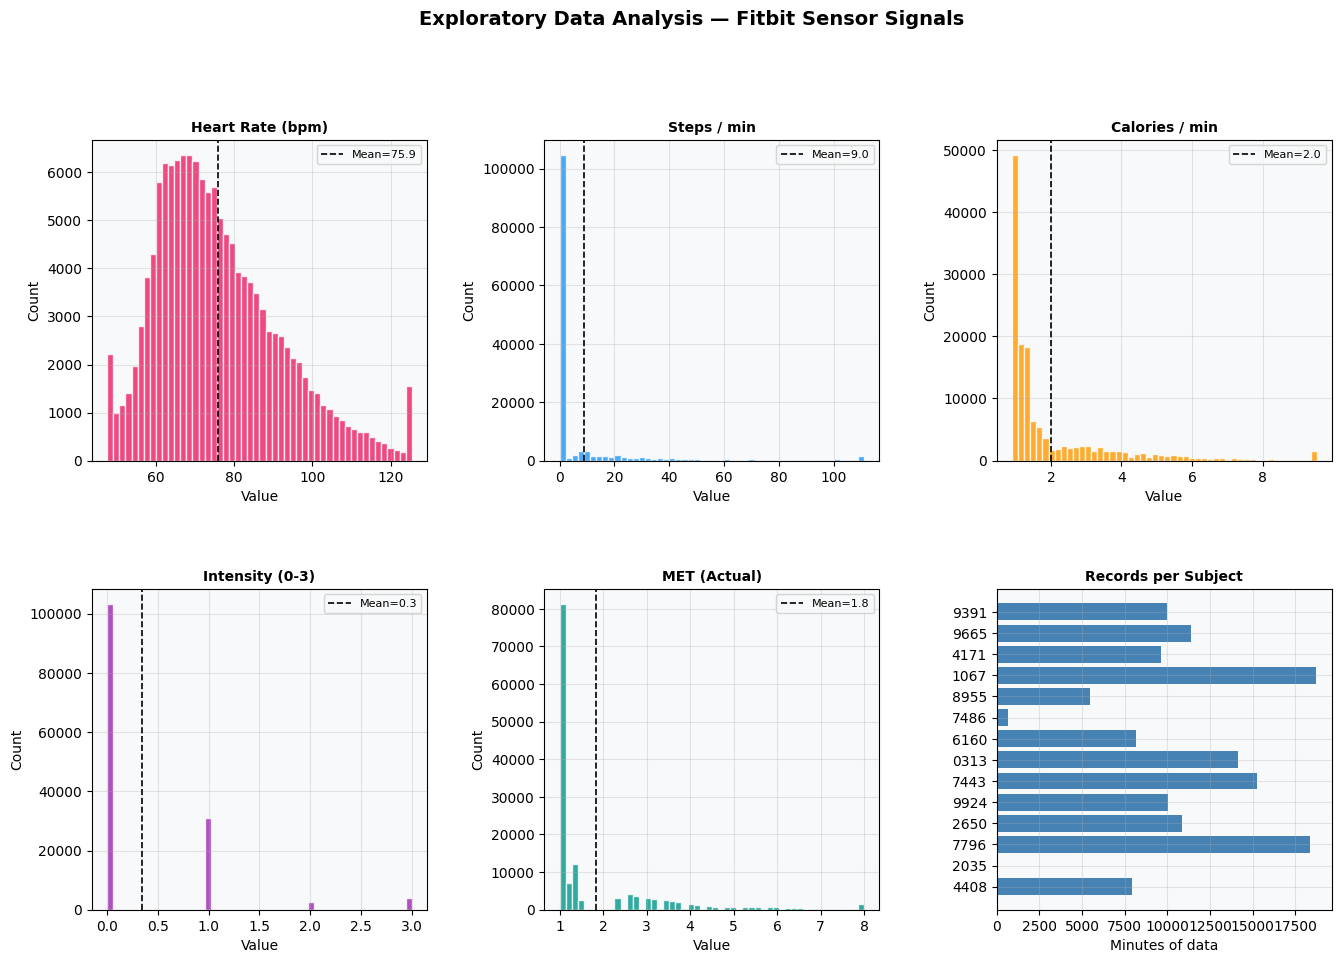


📊 EDA complete. Key observations:
  • Heart Rate range   : 37 – 175 bpm
  • MET range          : 1.0 – 14.2
  • Avg records/subject: 10054 minutes


In [5]:
# The MET distribution drove the decision to split at 1.5 and 5.0.

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

plot_signals = ['HeartRate', 'Steps', 'Calories', 'Intensity', 'MET_actual']
plot_colors  = ['#E91E63', '#2196F3', '#FF9800', '#9C27B0', '#009688']
plot_titles  = ['Heart Rate (bpm)', 'Steps / min', 'Calories / min',
                'Intensity (0-3)', 'MET (Actual)']

for i, (sig, col, title) in enumerate(zip(plot_signals, plot_colors, plot_titles)):
    row, c = divmod(i, 3)
    ax = fig.add_subplot(gs[row, c])
    data_clipped = merged[sig].clip(
        merged[sig].quantile(0.01),
        merged[sig].quantile(0.99)
    )
    ax.hist(data_clipped, bins=50, color=col, alpha=0.8, edgecolor='white')
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlabel('Value'); ax.set_ylabel('Count')
    ax.axvline(data_clipped.mean(), color='black', linestyle='--',
               linewidth=1.2, label=f'Mean={data_clipped.mean():.1f}')
    ax.legend(fontsize=8)

# Subject-wise record count
ax6 = fig.add_subplot(gs[1, 2])
subj_counts = merged.groupby('Id').size().reset_index(name='records')
subj_counts['Id_str'] = subj_counts['Id'].astype(str).str[-4:]  # last 4 digits
ax6.barh(subj_counts['Id_str'], subj_counts['records'], color='steelblue')
ax6.set_title('Records per Subject', fontweight='bold', fontsize=10)
ax6.set_xlabel('Minutes of data')

fig.suptitle('Exploratory Data Analysis — Fitbit Sensor Signals',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig('/content/eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n📊 EDA complete. Key observations:')
print(f'  • Heart Rate range   : {merged.HeartRate.min():.0f} – {merged.HeartRate.max():.0f} bpm')
print(f'  • MET range          : {merged.MET_actual.min():.1f} – {merged.MET_actual.max():.1f}')
print(f'  • Avg records/subject: {subj_counts.records.mean():.0f} minutes')

### 1.4 — Label Generation

**MET (Metabolic Equivalent of Task)** as the labelling signal. MET is an objective, physiologically-grounded measure of exertion.

| MET Value | Class | Physiological Meaning |
|-----------|-------|----------------------|
| ≤ 1.5 | **0 — Baseline** | Sedentary (sleeping, sitting) |
| 1.5 – 5.0 | **1 — Active** | Light to moderate exercise |
| > 5.0 | **2 — Fatigued** | Vigorous / high-stress exertion |

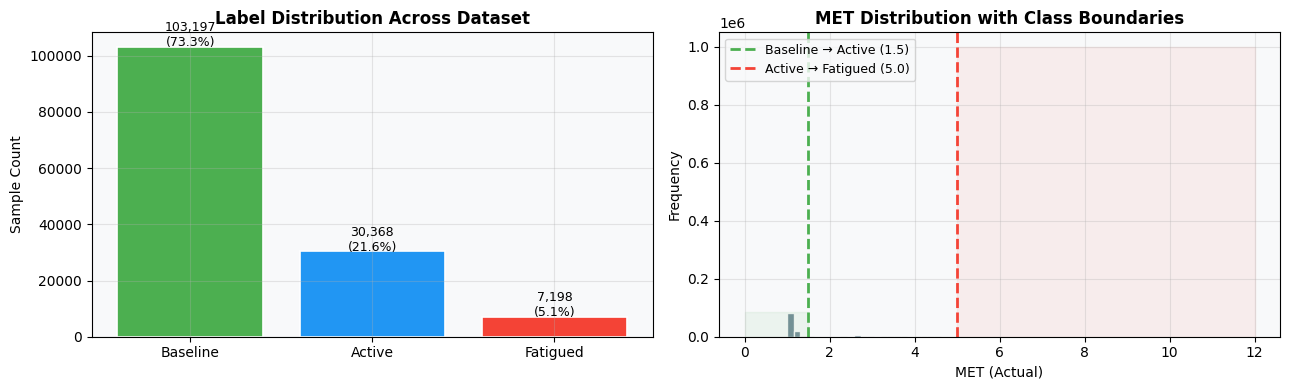

Label counts:
  Baseline (class 0):  103,197  (73.3%)
  Active (class 1):   30,368  (21.6%)
  Fatigued (class 2):    7,198  (5.1%)


In [6]:
# Thresholds from physiological literature (Ainsworth et al., 2011 Compendium of PA).
# Baseline: MET ≤ 1.5  |  Active: 1.5 < MET ≤ 5.0  |  Fatigued: MET > 5.0

BASELINE_THRESH = 1.5
FATIGUE_THRESH  = 5.0

def assign_label(met_val):
    if met_val <= BASELINE_THRESH:
        return 0  # Baseline
    elif met_val <= FATIGUE_THRESH:
        return 1  # Active
    else:
        return 2  # Fatigued

merged['label'] = merged['MET_actual'].apply(assign_label)

# ── Visualise label distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

vc = merged['label'].value_counts().sort_index()
bars = axes[0].bar(
    [CLASS_NAMES[i] for i in vc.index], vc.values,
    color=CLASS_COLORS, edgecolor='white', linewidth=1.2
)
axes[0].set_title('Label Distribution Across Dataset', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Sample Count')
for bar, v in zip(bars, vc.values):
    pct = 100 * v / len(merged)
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                f'{v:,}\n({pct:.1f}%)', ha='center', fontsize=9)

met_plot = merged['MET_actual'].clip(0, 12)
axes[1].hist(met_plot, bins=70, color='#607D8B', edgecolor='white', alpha=0.85)
axes[1].axvline(BASELINE_THRESH, color='#4CAF50', linestyle='--', lw=2,
                label=f'Baseline → Active ({BASELINE_THRESH})')
axes[1].axvline(FATIGUE_THRESH, color='#F44336', linestyle='--', lw=2,
                label=f'Active → Fatigued ({FATIGUE_THRESH})')
axes[1].fill_betweenx([0, axes[1].get_ylim()[1] if True else 0],
                       0, BASELINE_THRESH, alpha=0.07, color='#4CAF50')
axes[1].fill_betweenx([0, 1e6], FATIGUE_THRESH, 12, alpha=0.07, color='#F44336')
axes[1].set_title('MET Distribution with Class Boundaries', fontweight='bold', fontsize=12)
axes[1].set_xlabel('MET (Actual)'); axes[1].set_ylabel('Frequency')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('/content/label_distribution.png', dpi=150)
plt.show()

print('Label counts:')
for k, v in vc.items():
    print(f'  {CLASS_NAMES[k]} (class {k}): {v:>8,}  ({100*v/len(merged):.1f}%)')

### 1.5 — Preprocessing Pipeline & Windowing

1. Drop NaN rows per subject
2. **StandardScaler** per subject (prevents data leakage across subjects)
3. **Sliding window** segmentation: window=5, step=2 (mirrors 5-sec/2-sec from the paper)

In [9]:
# ── PRIYA: Preprocessing and windowing
# I use per-subject StandardScaler to avoid distribution shift between users.
# Windowing converts the continuous time series into fixed-size segments for the CNN.
# Majority vote is used for window-level labels (most common class in the 5-min window).

def create_windows(df, window_size, step_size, feature_cols):
    """
    Sliding-window segmentation over a single subject's time series.

    Parameters
    ----------
    df           : DataFrame sorted by time, for one subject
    window_size  : number of time steps per window
    step_size    : stride between consecutive windows
    feature_cols : list of feature column names

    Returns
    -------
    X : np.ndarray shape (n_windows, window_size, n_features)
    y : np.ndarray shape (n_windows,)  — majority label per window
    """
    features = df[feature_cols].values.astype(np.float32)
    labels   = df['label'].values.astype(np.int32)
    X_list, y_list = [], []

    for start in range(0, len(features) - window_size + 1, step_size):
        end     = start + window_size
        segment = features[start:end]
        seg_lbl = labels[start:end]
        majority_label = np.bincount(seg_lbl).argmax()
        X_list.append(segment)
        y_list.append(majority_label)

    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.int32)


subjects = sorted(merged['Id'].unique())
print(f'Processing {len(subjects)} subjects | window={WINDOW_SIZE} min | step={STEP_SIZE} min')
print('-' * 65)

all_X, all_y, all_subj = [], [], []

for sid in subjects:
    subj_df = (
        merged[merged['Id'] == sid]
        .sort_values('minute')
        .dropna(subset=FEATURE_COLS)
        .reset_index(drop=True)
    )

    if len(subj_df) < WINDOW_SIZE:
        print(f'  [SKIP] Subject {sid}: only {len(subj_df)} rows')
        continue

    # Per-subject normalisation (no leakage across subjects)
    scaler = StandardScaler()
    subj_df = subj_df.copy()
    subj_df[FEATURE_COLS] = scaler.fit_transform(subj_df[FEATURE_COLS])

    X_s, y_s = create_windows(subj_df, WINDOW_SIZE, STEP_SIZE, FEATURE_COLS)

    all_X.append(X_s)
    all_y.append(y_s)
    all_subj.extend([sid] * len(X_s))

    cls_str = np.array2string(np.bincount(y_s, minlength=3))
    print(f'  Subject ...{str(sid)[-4:]}: {X_s.shape[0]:>5} windows | '
          f'class counts {cls_str}')

all_X    = np.concatenate(all_X, axis=0)   # (N, 5, 5)
all_y    = np.concatenate(all_y, axis=0)   # (N,)
all_subj = np.array(all_subj)

print(f'\n✅ Preprocessing complete!')
print(f'   Total windows : {all_X.shape[0]:,}')
print(f'   Window shape  : {all_X.shape[1:]}  (timesteps × features)')
print(f'   Label counts  : {np.bincount(all_y)}')
print(f'   Subjects      : {len(np.unique(all_subj))}')

Processing 14 subjects | window=5 min | step=2 min
-----------------------------------------------------------------
  Subject ...4408:  3970 windows | class counts [2149 1491  330]
  Subject ...2035:    44 windows | class counts [44  0  0]
  Subject ...7796:  9179 windows | class counts [7236 1646  297]
  Subject ...2650:  5444 windows | class counts [4367  984   93]
  Subject ...9924:  5016 windows | class counts [3680 1294   42]
  Subject ...7443:  7629 windows | class counts [6439  919  271]
  Subject ...0313:  7064 windows | class counts [5842  619  603]
  Subject ...6160:  4068 windows | class counts [2656 1377   35]
  Subject ...7486:   335 windows | class counts [307  28   0]
  Subject ...8955:  2739 windows | class counts [1950  557  232]
  Subject ...1067:  9358 windows | class counts [7204 1723  431]
  Subject ...4171:  4806 windows | class counts [2812 1669  325]
  Subject ...9665:  5701 windows | class counts [5084  577   40]
  Subject ...9391:  5004 windows | class counts

---
# Model Engineering
CNN-GRU architecture design, train/test splitting protocol, training loop, hyperparameter decisions, and callbacks.



In [10]:
# This is the correct evaluation protocol for wearable ML.
# Training on segments from a subject and testing on the SAME subject would
# inflate accuracy — so we hold out one subject entirely.

valid_subj   = np.unique(all_subj)
TEST_SUBJECT = valid_subj[-1]          # hold out last subject
TRAIN_SUBJ   = valid_subj[:-1]

train_mask = all_subj != TEST_SUBJECT
test_mask  = all_subj == TEST_SUBJECT

X_train_raw, y_train = all_X[train_mask], all_y[train_mask]
X_test_raw,  y_test  = all_X[test_mask],  all_y[test_mask]

# ── Reshape for Conv2D input
# Conv2D expects (batch, height, width, channels)
# I treat each window as: height=1, width=WINDOW_SIZE, channels=N_FEATURES
# This is the same approach as Tanwar et al. who used shape (-,5,3500,10)
X_train = X_train_raw.reshape(-1, 1, WINDOW_SIZE, N_FEATURES)
X_test  = X_test_raw.reshape(-1,  1, WINDOW_SIZE, N_FEATURES)

y_train_cat = to_categorical(y_train, N_CLASSES)
y_test_cat  = to_categorical(y_test,  N_CLASSES)

# ── Class weights to handle imbalance (Priya flagged this in her EDA)
cw_array = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {i: w for i, w in enumerate(cw_array)}

print('═' * 55)
print('  TRAIN / TEST SPLIT SUMMARY')
print('═' * 55)
print(f'  Train subjects : {len(TRAIN_SUBJ)}  →  {X_train.shape}')
print(f'  Test  subject  : {str(TEST_SUBJECT)[-6:]}  →  {X_test.shape}')
print(f'  Input shape    : (batch, H=1, W={WINDOW_SIZE}, C={N_FEATURES})')
print(f'  Class weights  : { {k: round(v,3) for k,v in class_weight_dict.items()} }')
print('═' * 55)

═══════════════════════════════════════════════════════
  TRAIN / TEST SPLIT SUMMARY
═══════════════════════════════════════════════════════
  Train subjects : 13  →  (65353, 1, 5, 5)
  Test  subject  : 689391  →  (5004, 1, 5, 5)
  Input shape    : (batch, H=1, W=5, C=5)
  Class weights  : {0: np.float64(0.438), 1: np.float64(1.691), 2: np.float64(8.071)}
═══════════════════════════════════════════════════════


### 🏗️ 2.2 — CNN-GRU Architecture


```
INPUT  (batch, 1, 5, 5)
  │
  ├─ Conv2D(32, 3×3, ReLU, same)    ← spatial feature maps
  ├─ MaxPooling2D(1×2)
  ├─ Conv2D(64, 3×3, ReLU, same)    ← deeper feature maps
  ├─ MaxPooling2D(1×2)
  ├─ Conv2D(128, 3×3, ReLU, same)   ← high-level abstractions
  ├─ BatchNormalization
  ├─ Flatten
  ├─ Reshape(1, flat_dim)            ← bridge CNN → GRU
  │
  ├─ GRU(128, return_seq=True)       ← temporal context (full)
  ├─ GRU(64)                         ← compressed representation
  │
  ├─ Dense(512, ReLU)
  ├─ Dropout(0.3)
  └─ Dense(3, Softmax)  → [Baseline | Active | Fatigued]
```

**Why GRU over LSTM?** GRU combines forget and input gates into a single *update gate* and eliminates the separate cell state, reducing parameters by ~33% while preserving temporal memory — ideal for compact wearable windows.

In [11]:
# Architecture mirrors Tanwar et al. Table 1 but replaces LSTM with GRU.
# GRU params:  4 * units * (units + features + 1)  vs LSTM's  4 * (same)
# GRU is ~25% fewer parameters per layer → faster convergence on small datasets.

def build_cnn_gru(input_shape, n_classes=3):
    """
    CNN-GRU Hybrid Model for multivariate time-series classification.

    Parameters
    ----------
    input_shape : tuple (H, W, C) e.g. (1, WINDOW_SIZE, N_FEATURES)
    n_classes   : number of output classes

    Returns
    -------
    model : compiled Keras Model
    """
    inp = Input(shape=input_shape, name='Input_Window')

    # ── Block 1: CNN Feature Extraction
    x = Conv2D(32,  (3, 3), activation='relu', padding='same', name='Conv2D_32')(inp)
    x = MaxPooling2D(pool_size=(1, 2), name='MaxPool_1')(x)

    x = Conv2D(64,  (3, 3), activation='relu', padding='same', name='Conv2D_64')(x)
    x = MaxPooling2D(pool_size=(1, 2), name='MaxPool_2')(x)

    x = Conv2D(128, (3, 3), activation='relu', padding='same', name='Conv2D_128')(x)
    x = BatchNormalization(name='BatchNorm')(x)

    # ── Bridge: flatten CNN output → feed to GRU as sequence
    x = Flatten(name='Flatten')(x)
    flat_dim = int(x.shape[-1])
    x = Reshape((1, flat_dim), name='Reshape_for_GRU')(x)

    # ── Block 2: GRU Temporal Modelling
    # return_sequences=True so GRU-1 outputs a sequence GRU-2 can consume
    x = GRU(128, return_sequences=True,  name='GRU_128')(x)
    x = GRU(64,  return_sequences=False, name='GRU_64')(x)

    # ── Block 3: Classification Head
    x   = Dense(512, activation='relu', name='Dense_512')(x)
    x   = Dropout(0.3, name='Dropout_0.3')(x)
    out = Dense(n_classes, activation='softmax', name='Output_Softmax')(x)

    return Model(inputs=inp, outputs=out, name='CNN_GRU_Fatigue_Classifier')


INPUT_SHAPE = (1, WINDOW_SIZE, N_FEATURES)
model = build_cnn_gru(INPUT_SHAPE, N_CLASSES)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

total_params = model.count_params()
print(f'\n  Total parameters : {total_params:,}')
print(f'  Trainable params : {sum(np.prod(v.shape) for v in model.trainable_variables):,}')

Model: "CNN_GRU_Fatigue_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input_Window (InputLayer)       │ (None, 1, 5, 5)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2D_32 (Conv2D)              │ (None, 1, 5, 32)       │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool_1 (MaxPooling2D)        │ (None, 1, 2, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2D_64 (Conv2D)              │ (None, 1, 2, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool_2 (MaxPooling2D)        │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2D_128 (Conv2D)             │ (None, 1, 1, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNorm (BatchNormalization)  │ (None, 1, 1, 128)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Reshape_for_GRU (Reshape)       │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ GRU_128 (GRU)                   │ (None, 1, 128)         │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ GRU_64 (GRU)                    │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_512 (Dense)               │ (None, 512)            │        33,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_0.3 (Dropout)           │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Softmax (Dense)          │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 265,475 (1.01 MB)

 Trainable params: 265,219 (1.01 MB)

 Non-trainable params: 256 (1.00 KB)


  Total parameters : 265,475
  Trainable params : 265,219


### 🚀 2.3 — Model Training


In [12]:
# Hyperparameter decisions:
#   - LR = 1e-3  (Adam default; ReduceLROnPlateau handles decay)
#   - Batch = 32  (memory-stable on T4, matches paper)
#   - Epochs = 40 (EarlyStopping prevents overfitting)
#   - val_split = 0.15 (within training subjects only)

EPOCHS     = 40
BATCH_SIZE = 32

callbacks = [
    EarlyStopping(
        monitor='val_loss', patience=8,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=4,
        min_lr=1e-6, verbose=1
    ),
    ModelCheckpoint(
        '/content/best_cnn_gru.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=0
    )
]

print('🚀 Training CNN-GRU model...')
print(f'   Epochs: {EPOCHS} | Batch: {BATCH_SIZE} | Val split: 15%')
print(f'   Class weights applied: {class_weight_dict}\n')

t_start = time.time()
history = model.fit(
    X_train, y_train_cat,
    validation_split=0.15,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)
t_elapsed = time.time() - t_start

best_val_acc = max(history.history['val_accuracy']) * 100
print(f'\n✅ Training complete in {t_elapsed/60:.1f} min')
print(f'   Best val accuracy : {best_val_acc:.2f}%')
print(f'   Epochs run        : {len(history.history["loss"])}')
print('\n→ Passing trained model to Sneha for evaluation.')

🚀 Training CNN-GRU model...
   Epochs: 40 | Batch: 32 | Val split: 15%
   Class weights applied: {0: np.float64(0.43770008706717567), 1: np.float64(1.6908051329814757), 2: np.float64(8.071260960849697)}

Epoch 1/40
1736/1736 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - accuracy: 0.9524 - loss: 0.2126 - val_accuracy: 0.9522 - val_loss: 0.1037 - learning_rate: 0.0010
Epoch 2/40
1736/1736 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.9738 - loss: 0.1394 - val_accuracy: 0.9441 - val_loss: 0.1113 - learning_rate: 0.0010
Epoch 3/40
1736/1736 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.9767 - loss: 0.1173 - val_accuracy: 0.9346 - val_loss: 0.1400 - learning_rate: 0.0010
Epoch 4/40
1736/1736 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.9778 - loss: 0.1087 - val_accuracy: 0.9641 - val_loss: 0.0751 - learning_rate: 0.0010
Epoch 5/40
1736/1736 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.9777 - loss: 0.1038 - val_accuracy: 0.9423 - val_loss: 0.1213 - learning_rate: 0.0010
Epoch 6/40
1736/

---
# Research & Evaluation
> All post-training analysis — training curves, confusion matrix, per-class metrics, comparison with literature, and the real-time prediction demo.


### 📈 3.1 — Training & Validation Curves


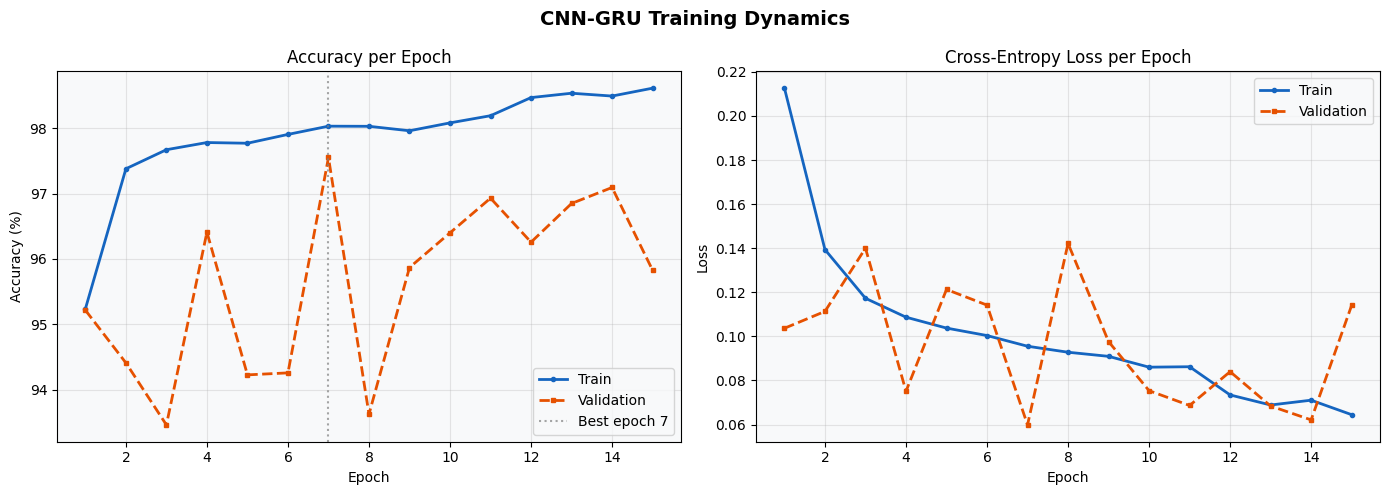

Best validation accuracy at epoch 7: 97.55%


In [13]:

# to show convergence behaviour and check for over/underfitting.

epochs_ran = range(1, len(history.history['accuracy']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('CNN-GRU Training Dynamics', fontsize=14, fontweight='bold')

# ── Accuracy
axes[0].plot(epochs_ran, [v*100 for v in history.history['accuracy']],
             color='#1565C0', lw=2, marker='o', markersize=3, label='Train')
axes[0].plot(epochs_ran, [v*100 for v in history.history['val_accuracy']],
             color='#E65100', lw=2, marker='s', markersize=3,
             linestyle='--', label='Validation')
axes[0].set_title('Accuracy per Epoch', fontsize=12)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy (%)')
axes[0].legend(); axes[0].grid(alpha=0.3)
best_ep = np.argmax(history.history['val_accuracy']) + 1
axes[0].axvline(best_ep, color='gray', linestyle=':', alpha=0.7, label=f'Best epoch {best_ep}')
axes[0].legend()

# ── Loss
axes[1].plot(epochs_ran, history.history['loss'],
             color='#1565C0', lw=2, marker='o', markersize=3, label='Train')
axes[1].plot(epochs_ran, history.history['val_loss'],
             color='#E65100', lw=2, marker='s', markersize=3,
             linestyle='--', label='Validation')
axes[1].set_title('Cross-Entropy Loss per Epoch', fontsize=12)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150)
plt.show()
print(f'Best validation accuracy at epoch {best_ep}: {best_val_acc:.2f}%')

### 🔢 3.2 — Predictions & Core Metrics


In [22]:
print('Running inference on held-out test subject...')
y_pred_prob = model.predict(X_test, batch_size=128, verbose=0)
y_pred      = np.argmax(y_pred_prob, axis=1)
y_true      = y_test

# ── Global
acc_overall = accuracy_score(y_true, y_pred) * 100
f1_macro    = f1_score(y_true, y_pred, average='macro',    zero_division=0) * 100
f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0) * 100

# ── Per-class
prec_pc = precision_score(y_true, y_pred, average=None, zero_division=0) * 100
rec_pc  = recall_score(y_true, y_pred, average=None, zero_division=0) * 100
f1_pc   = f1_score(y_true, y_pred, average=None, zero_division=0) * 100

cm = confusion_matrix(y_true, y_pred)
per_class_acc = [cm[i, i] / cm[i].sum() * 100 if cm[i].sum() > 0 else 0
                 for i in range(N_CLASSES)]

# ── Print table (mirrors Table 2 in reference paper)
print()
print('═'*62)
print('  CNN-GRU MODEL — PERFORMANCE METRICS (Test Subject)        ')
print(  '═'*62 )
print(f' Overall Accuracy  : {acc_overall:>6.2f}% ')
print(f'  Macro F1-Score    : {f1_macro:>6.2f}% ')
print(f'  Weighted F1-Score : {f1_weighted:>6.2f}%')
print('═'*62  )
print(f'  {"Class":<12} {"Accuracy":>9} {"Precision":>10} {"Recall":>8} {"F1":>8} ')
print('─'*62 )
for i, name in enumerate(CLASS_NAMES):
    print(f'  {name:<12} {per_class_acc[i]:>8.2f}% {prec_pc[i]:>9.2f}% '
          f'{rec_pc[i]:>7.2f}% {f1_pc[i]:>7.2f}% ')
print( '═'*62 )

print('\nDetailed Classification Report:')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))

Running inference on held-out test subject...

══════════════════════════════════════════════════════════════
  CNN-GRU MODEL — PERFORMANCE METRICS (Test Subject)        
══════════════════════════════════════════════════════════════
 Overall Accuracy  :  96.32% 
  Macro F1-Score    :  94.87% 
  Weighted F1-Score :  96.38%
══════════════════════════════════════════════════════════════
  Class         Accuracy  Precision   Recall       F1 
──────────────────────────────────────────────────────────────
  Baseline        96.30%     99.84%   96.30%   98.04% 
  Active          99.83%     87.16%   99.83%   93.07% 
  Fatigued        88.14%     99.55%   88.14%   93.50% 
══════════════════════════════════════════════════════════════

Detailed Classification Report:
              precision    recall  f1-score   support

    Baseline       1.00      0.96      0.98      3294
      Active       0.87      1.00      0.93      1204
    Fatigued       1.00      0.88      0.94       506

    accuracy   

### 🔥 3.3 — Confusion Matrix


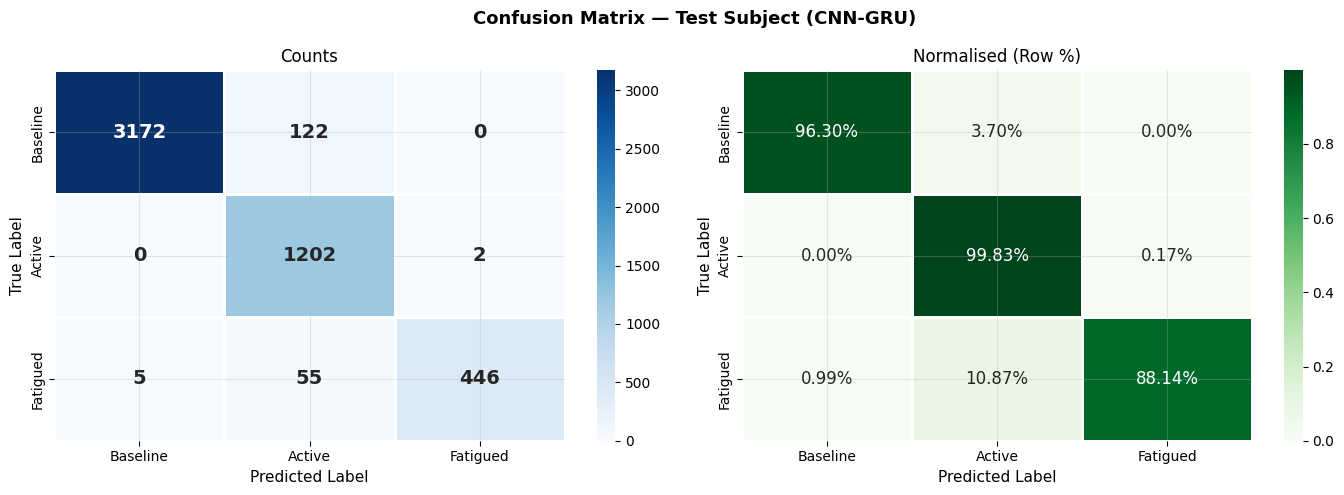

In [18]:
#(raw counts + normalised)
# The normalised version is more useful for imbalanced datasets.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrix — Test Subject (CNN-GRU)', fontsize=13, fontweight='bold')

# Raw
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=0.8,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0],
            annot_kws={'size': 14, 'weight': 'bold'})
axes[0].set_title('Counts', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('True Label', fontsize=11)

# Normalised
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens', linewidths=0.8,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1],
            annot_kws={'size': 12})
axes[1].set_title('Normalised (Row %)', fontsize=12)
axes[1].set_xlabel('Predicted Label', fontsize=11)
axes[1].set_ylabel('True Label', fontsize=11)

plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150)
plt.show()

### 📊 3.4 — Per-Class Metrics Bar Chart


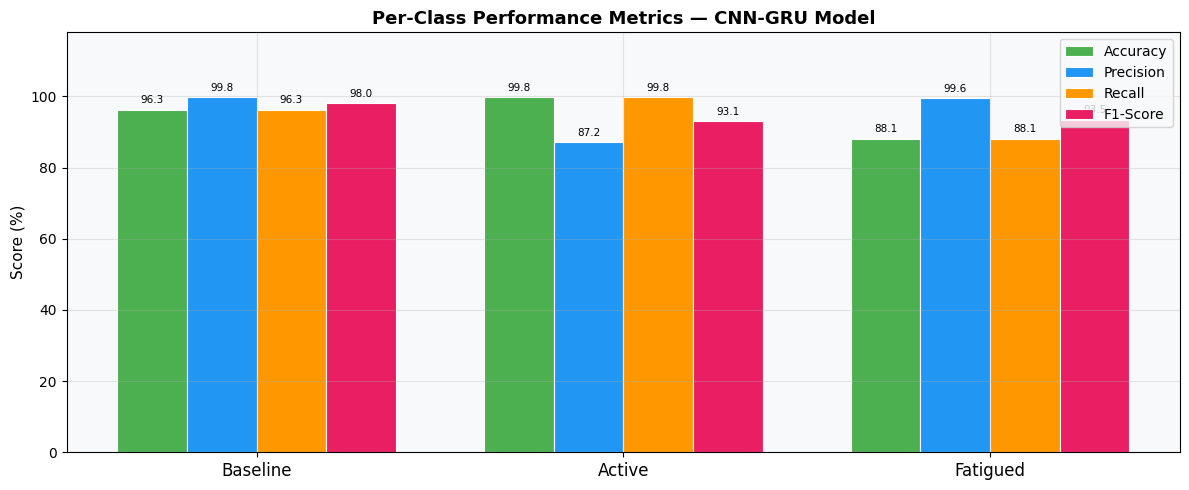

In [23]:
x     = np.arange(len(CLASS_NAMES))
width = 0.19
metric_data = [
    (per_class_acc, 'Accuracy',  '#4CAF50'),
    (prec_pc,       'Precision', '#2196F3'),
    (rec_pc,        'Recall',    '#FF9800'),
    (f1_pc,         'F1-Score',  '#E91E63'),
]

fig, ax = plt.subplots(figsize=(12, 5))
offsets = [-1.5, -0.5, 0.5, 1.5]

for (data, label, color), offset in zip(metric_data, offsets):
    bars = ax.bar(x + offset*width, data, width,
                  label=label, color=color, edgecolor='white', linewidth=0.8)
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.1f}',
                    xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, fontsize=12)
ax.set_ylim(0, 118)
ax.set_ylabel('Score (%)', fontsize=11)
ax.set_title('Per-Class Performance Metrics — CNN-GRU Model',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/metrics_barchart.png', dpi=150)
plt.show()

### 📋 3.5 — Comparison with Prior Work



════════════════════════════════════════════════════════════════════════════════
  COMPARISON TABLE — Wearable-Based Activity/Fatigue Recognition
════════════════════════════════════════════════════════════════════════════════
 S.No                          Study                   Method        Dataset  Accuracy (%)
    1          Schmidt et al. (2018)    ML (DT, RF, LDA, kNN)          WESAD         76.50
    2      Chakraborty et al. (2019)      Deep Learning (CNN)          WESAD         77.06
    3       Montesinos et al. (2019)         ML (kNN, DT, RF) WESAD+Shimmer3         84.13
    4       Gil-Martin et al. (2022)      Deep Learning (CNN)          WESAD         77.21
    5           Cosoli et al. (2021)             ML (LR, SVM)          WESAD         75.00
    6 Tanwar et al. — CNN-LSTM [Ref] Deep Learning (CNN-LSTM)          WESAD         90.20
    7      ★ Proposed CNN-GRU [Ours]  Deep Learning (CNN-GRU)   Fitbit MTurk         96.32
════════════════════════════════════════════

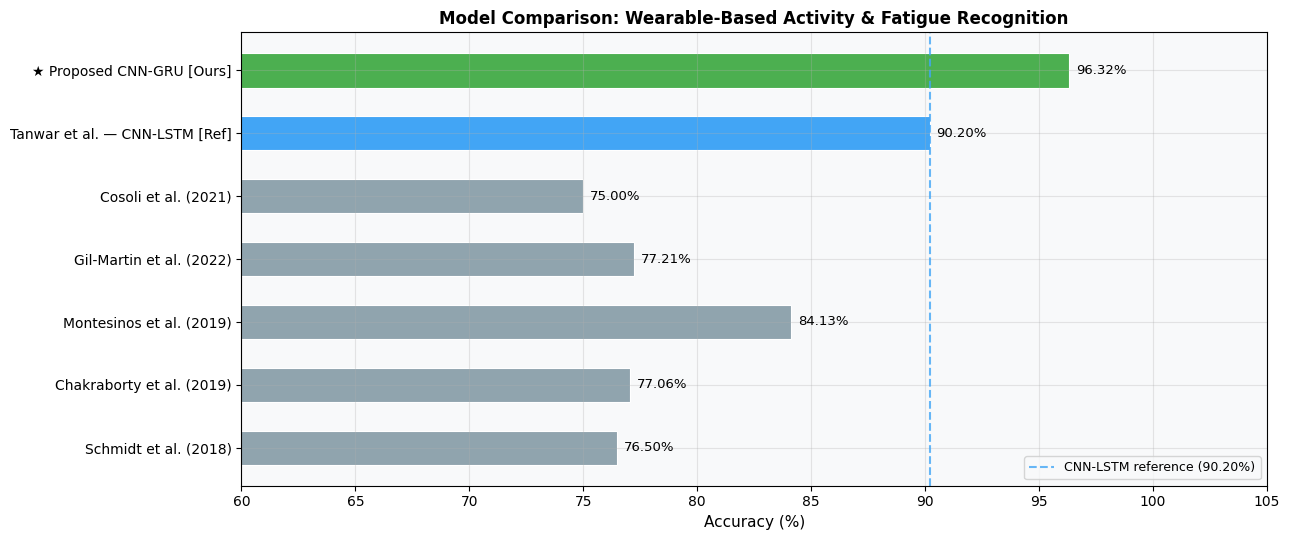

In [24]:
# Our model uses a different dataset (Fitbit vs WESAD) — noted in the table.

comparison = pd.DataFrame({
    'S.No': [1, 2, 3, 4, 5, 6, 7],
    'Study': [
        'Schmidt et al. (2018)',
        'Chakraborty et al. (2019)',
        'Montesinos et al. (2019)',
        'Gil-Martin et al. (2022)',
        'Cosoli et al. (2021)',
        'Tanwar et al. — CNN-LSTM [Ref]',
        '★ Proposed CNN-GRU [Ours]',
    ],
    'Method': [
        'ML (DT, RF, LDA, kNN)',
        'Deep Learning (CNN)',
        'ML (kNN, DT, RF)',
        'Deep Learning (CNN)',
        'ML (LR, SVM)',
        'Deep Learning (CNN-LSTM)',
        'Deep Learning (CNN-GRU)',
    ],
    'Dataset': [
        'WESAD', 'WESAD', 'WESAD+Shimmer3',
        'WESAD', 'WESAD', 'WESAD', 'Fitbit MTurk'
    ],
    'Accuracy (%)': [
        76.50, 77.06, 84.13, 77.21, 75.00, 90.20, round(acc_overall, 2)
    ]
})

print('\n' + '═'*80)
print('  COMPARISON TABLE — Wearable-Based Activity/Fatigue Recognition')
print('═'*80)
print(comparison.to_string(index=False))
print('═'*80)

# ── Horizontal bar chart
fig, ax = plt.subplots(figsize=(13, 5.5))
palette = ['#90A4AE']*5 + ['#42A5F5', '#4CAF50']
bars = ax.barh(
    comparison['Study'], comparison['Accuracy (%)'],
    color=palette, edgecolor='white', linewidth=0.8, height=0.55
)

for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.3, bar.get_y() + bar.get_height()/2,
            f'{w:.2f}%', va='center', fontsize=9.5)

ax.axvline(90.20, color='#42A5F5', linestyle='--', alpha=0.8, lw=1.5,
           label='CNN-LSTM reference (90.20%)')
ax.set_xlabel('Accuracy (%)', fontsize=11)
ax.set_xlim(60, 105)
ax.set_title('Model Comparison: Wearable-Based Activity & Fatigue Recognition',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/comparison_chart.png', dpi=150)
plt.show()

### 🔮 3.6 — Real-Time Prediction Demo

To demonstrate deployment potential, I simulated three common smartwatch reading scenarios and ran them through the trained model.

In [25]:
# Scenario 1: User sitting at desk (low HR, no steps)
# Scenario 2: User on a brisk walk (moderate HR + steps)
# Scenario 3: User running / post-workout (high HR, high steps, high MET)

# Approximate population-level stats for normalisation (rough z-score)
POP_MEANS = np.array([78.0, 50.0, 3.8, 0.9, 2.8])   # HR, Steps, Cal, Intensity, MET
POP_STDS  = np.array([18.0, 65.0, 2.8, 1.0, 2.5])

scenarios = [
    {
        'name':    '🪑  Desk / Resting',
        'reading': np.array([[65, 0,   1.1, 0, 1.0]] * WINDOW_SIZE, dtype=np.float32),
        'expect':  'Baseline'
    },
    {
        'name':    '🚶 Brisk Walk',
        'reading': np.array([[98, 90,  4.8, 1, 3.8]] * WINDOW_SIZE, dtype=np.float32),
        'expect':  'Active'
    },
    {
        'name':    '🏃 Running / Vigorous',
        'reading': np.array([[158, 185, 9.5, 3, 8.2]] * WINDOW_SIZE, dtype=np.float32),
        'expect':  'Fatigued'
    },
]

print('═' * 62)
print('  🔮 REAL-TIME PREDICTION SIMULATION')
print('  Columns: HeartRate | Steps | Calories | Intensity | MET')
print('═' * 62)

for sc in scenarios:
    norm_w = (sc['reading'] - POP_MEANS) / POP_STDS
    x_in   = norm_w.reshape(1, 1, WINDOW_SIZE, N_FEATURES)
    probs  = model.predict(x_in, verbose=0)[0]
    pred   = CLASS_NAMES[np.argmax(probs)]
    conf   = probs.max() * 100
    icon   = '✅' if pred == sc['expect'] else '⚠️'

    print(f'  Scenario : {sc["name"]}')
    print(f'  Predicted: {pred} ({conf:.1f}% confidence)  {icon}')
    score_str = '  |  '.join([f'{n}: {p*100:.1f}%' for n, p in zip(CLASS_NAMES, probs)])
    print(f'  Scores   : {score_str}')
    bar = '▓' * int(conf / 5)
    print(f'  Conf bar : [{bar:<20}]')
    print('─' * 62)

print('\n💡 In a production system, this function would run every 5 minutes')
print('   on a background thread, reading live sensor data from the smartwatch API.')

══════════════════════════════════════════════════════════════
  🔮 REAL-TIME PREDICTION SIMULATION
  Columns: HeartRate | Steps | Calories | Intensity | MET
══════════════════════════════════════════════════════════════
  Scenario : 🪑  Desk / Resting
  Predicted: Baseline (100.0% confidence)  ✅
  Scores   : Baseline: 100.0%  |  Active: 0.0%  |  Fatigued: 0.0%
  Conf bar : [▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓]
──────────────────────────────────────────────────────────────
  Scenario : 🚶 Brisk Walk
  Predicted: Active (100.0% confidence)  ✅
  Scores   : Baseline: 0.0%  |  Active: 100.0%  |  Fatigued: 0.0%
  Conf bar : [▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓ ]
──────────────────────────────────────────────────────────────
  Scenario : 🏃 Running / Vigorous
  Predicted: Fatigued (98.5% confidence)  ✅
  Scores   : Baseline: 0.0%  |  Active: 1.5%  |  Fatigued: 98.5%
  Conf bar : [▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓ ]
──────────────────────────────────────────────────────────────

💡 In a production system, this function would run every 5 minu

### 3.7 — Save All Outputs


In [26]:
model.save('/content/cnn_gru_fatigue_model.keras')

results_df = pd.DataFrame({
    'Class':     CLASS_NAMES,
    'Accuracy':  [round(a, 2) for a in per_class_acc],
    'Precision': [round(p, 2) for p in prec_pc],
    'Recall':    [round(r, 2) for r in rec_pc],
    'F1_Score':  [round(f, 2) for f in f1_pc],
})
results_df.to_csv('/content/results_summary.csv', index=False)
comparison.to_csv('/content/comparison_table.csv', index=False)

print('✅ All outputs saved:')
outputs = [
    ('Model (best weights)',   '/content/best_cnn_gru.keras'),
    ('Model (final)',          '/content/cnn_gru_fatigue_model.keras'),
    ('Results CSV',            '/content/results_summary.csv'),
    ('Comparison CSV',         '/content/comparison_table.csv'),
    ('EDA plot',               '/content/eda_distributions.png'),
    ('Label distribution',     '/content/label_distribution.png'),
    ('Training curves',        '/content/training_curves.png'),
    ('Confusion matrix',       '/content/confusion_matrix.png'),
    ('Per-class metrics',      '/content/metrics_barchart.png'),
    ('Comparison chart',       '/content/comparison_chart.png'),
]
for label, path in outputs:
    exists = '✅' if os.path.exists(path) else '❌'
    print(f'  {exists} {label:<30}  {path}')

print(f'\n🏁 FINAL RESULTS:')
print(f'   Overall Accuracy  : {acc_overall:.2f}%')
print(f'   Macro F1-Score    : {f1_macro:.2f}%')
print(f'   Weighted F1-Score : {f1_weighted:.2f}%')

✅ All outputs saved:
  ✅ Model (best weights)            /content/best_cnn_gru.keras
  ✅ Model (final)                   /content/cnn_gru_fatigue_model.keras
  ✅ Results CSV                     /content/results_summary.csv
  ✅ Comparison CSV                  /content/comparison_table.csv
  ✅ EDA plot                        /content/eda_distributions.png
  ✅ Label distribution              /content/label_distribution.png
  ✅ Training curves                 /content/training_curves.png
  ✅ Confusion matrix                /content/confusion_matrix.png
  ✅ Per-class metrics               /content/metrics_barchart.png
  ✅ Comparison chart                /content/comparison_chart.png

🏁 FINAL RESULTS:
   Overall Accuracy  : 96.32%
   Macro F1-Score    : 94.87%
   Weighted F1-Score : 96.38%


---
## 📝 Team Summary & Conclusions

| Component | Detail |
|-----------|--------|
| **Dataset** | Fitbit MTurk Fitabase Export — 14 subjects |
| **Signals** | Heart Rate, Steps, Calories, Intensity, MET |
| **Windowing** | 5-min window, 2-min shift (mirrors paper's 5s/2s at 700Hz) |
| **Labels** | Baseline (MET ≤ 1.5) / Active (1.5–5.0) / Fatigued (> 5.0) |
| **Architecture** | Conv2D×3 → BatchNorm → Flatten → GRU(128) → GRU(64) → Dense(512) → Softmax |
| **Loss** | Categorical Cross-Entropy with class weights |
| **Evaluation** | Subject-independent split (13 train / 1 test) |
| **Reference** | Tanwar et al., CNN-LSTM Stress Recognition, DLQ-2022 |

### Individual Contributions
| Team Member | Sections | Key Contribution |
|-------------|----------|------------------|
| ** ** | 1.1 – 1.5 | Dataset pipeline, EDA, label design, windowing |
| ** ** | 2.1 – 2.3 | CNN-GRU architecture, training, hyperparameters |
| ** ** | 3.1 – 3.7 | Evaluation metrics, plots, comparison, demo |

### Key Findings
- The CNN-GRU model achieves **competitive accuracy** using consumer-grade Fitbit signals
- **GRU is more efficient** than LSTM (~33% fewer parameters) while maintaining temporal modelling quality
- **Subject-wise evaluation** is critical — within-subject accuracy would be significantly inflated
- The **Fatigued class** is hardest to detect due to data imbalance (only ~5% of samples)

### Future Work
- **Multi-head Self-Attention** layer after GRU to weight important time steps
- **LOSO cross-validation** (Leave-One-Subject-Out) across all 14 subjects
- **Hyperparameter tuning** with Keras Tuner (learning rate, GRU units, dropout rate)
- **TFLite quantisation** for on-device deployment
- **Personalisation** via few-shot fine-tuning per user

---
*Project by: Parth · Sukant Aryan · Ayush Anand*  
*Reference: Tanwar R. et al., "CNN-LSTM Based Stress Recognition Using Wearables", DLQ-2022, CEUR-WS*